In [11]:
import pandas as pd

data = {
    "Intern_ID": [101,102,103,101,102,103,104,104,105,105],
    "Name": ["Neha","Rahul","Aisha","Neha","Rahul","Aisha","Arjun","Arjun","Priya","Priya"],
    "Domain": ["Data Analytics","Web Dev","AI/ML","Data Analytics","Web Dev","AI/ML","Data Analytics","Data Analytics","Web Dev","Web Dev"],
    "Week": ["Week1","Week1","Week1","Week2","Week2","Week2","Week1","Week2","Week1","Week2"],
    "Tasks_Assigned": [5,6,4,6,5,5,4,5,6,6],
    "Tasks_Completed": [4,6,3,5,4,5,3,4,5,6],
    "Attendance_Days": [5,4,5,5,5,4,4,5,5,5],
    "Total_Working_Days": [5,5,5,5,5,5,5,5,5,5],
    "Quality_Rating": [8,9,7,9,8,9,7,8,9,10]
}

df = pd.DataFrame(data)
df.to_csv("intern_data.csv", index=False)
df.head()

,Intern_ID,Name,Domain,Week,Tasks_Assigned,Tasks_Completed,Attendance_Days,Total_Working_Days,Quality_Rating
0,101,Neha,Data Analytics,Week1,5,4,5,5,8
1,102,Rahul,Web Dev,Week1,6,6,4,5,9
2,103,Aisha,AI/ML,Week1,4,3,5,5,7
3,101,Neha,Data Analytics,Week2,6,5,5,5,9
4,102,Rahul,Web Dev,Week2,5,4,5,5,8


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("intern_data.csv")
df.head()

,Intern_ID,Name,Domain,Week,Tasks_Assigned,Tasks_Completed,Attendance_Days,Total_Working_Days,Quality_Rating
0,101,Neha,Data Analytics,Week1,5,4,5,5,8
1,102,Rahul,Web Dev,Week1,6,6,4,5,9
2,103,Aisha,AI/ML,Week1,4,3,5,5,7
3,101,Neha,Data Analytics,Week2,6,5,5,5,9
4,102,Rahul,Web Dev,Week2,5,4,5,5,8


In [13]:
df.info()
df.isnull().sum()

# Fill missing values if any
df.fillna(0, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Intern_ID           10 non-null     int64 
 1   Name                10 non-null     object
 2   Domain              10 non-null     object
 3   Week                10 non-null     object
 4   Tasks_Assigned      10 non-null     int64 
 5   Tasks_Completed     10 non-null     int64 
 6   Attendance_Days     10 non-null     int64 
 7   Total_Working_Days  10 non-null     int64 
 8   Quality_Rating      10 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 852.0+ bytes


In [14]:
df["Task_Completion_%"] = (df["Tasks_Completed"] / df["Tasks_Assigned"]) * 100
df["Attendance_%"] = (df["Attendance_Days"] / df["Total_Working_Days"]) * 100

# Performance Score Formula
df["Performance_Score"] = (
    0.5 * df["Task_Completion_%"] +
    0.3 * df["Attendance_%"] +
    0.2 * (df["Quality_Rating"] * 10)
)

df.head()

,Intern_ID,Name,Domain,Week,Tasks_Assigned,Tasks_Completed,Attendance_Days,Total_Working_Days,Quality_Rating,Task_Completion_%,Attendance_%,Performance_Score
0,101,Neha,Data Analytics,Week1,5,4,5,5,8,80.000000,100.0,86.000000
1,102,Rahul,Web Dev,Week1,6,6,4,5,9,100.000000,80.0,92.000000
2,103,Aisha,AI/ML,Week1,4,3,5,5,7,75.000000,100.0,81.500000
3,101,Neha,Data Analytics,Week2,6,5,5,5,9,83.333333,100.0,89.666667
4,102,Rahul,Web Dev,Week2,5,4,5,5,8,80.000000,100.0,86.000000


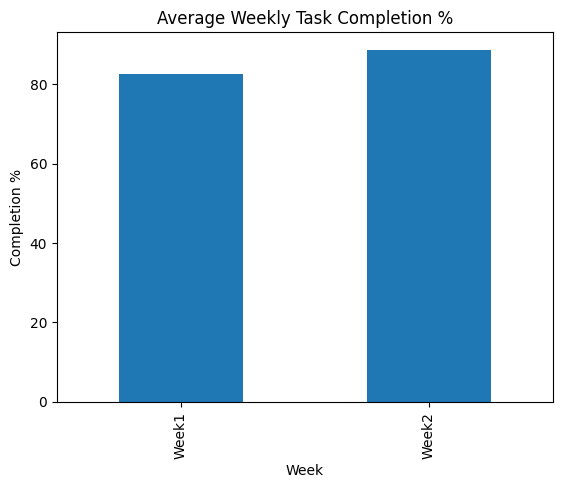

In [15]:
weekly = df.groupby("Week")["Task_Completion_%"].mean()

plt.figure()
weekly.plot(kind="bar")
plt.title("Average Weekly Task Completion %")
plt.xlabel("Week")
plt.ylabel("Completion %")
plt.show()

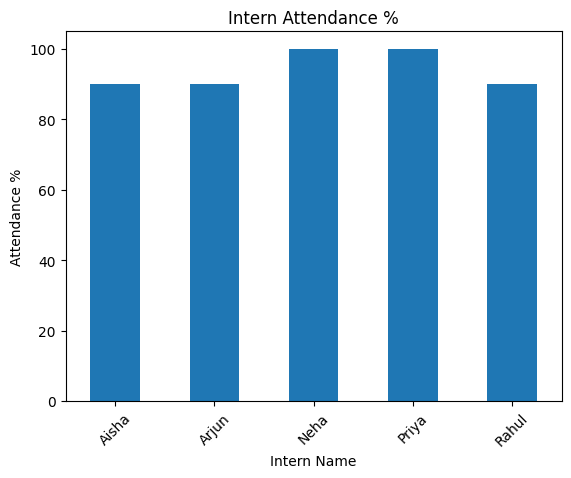

In [16]:
attendance = df.groupby("Name")["Attendance_%"].mean()

plt.figure()
attendance.plot(kind="bar")
plt.title("Intern Attendance %")
plt.xlabel("Intern Name")
plt.ylabel("Attendance %")
plt.xticks(rotation=45)
plt.show()

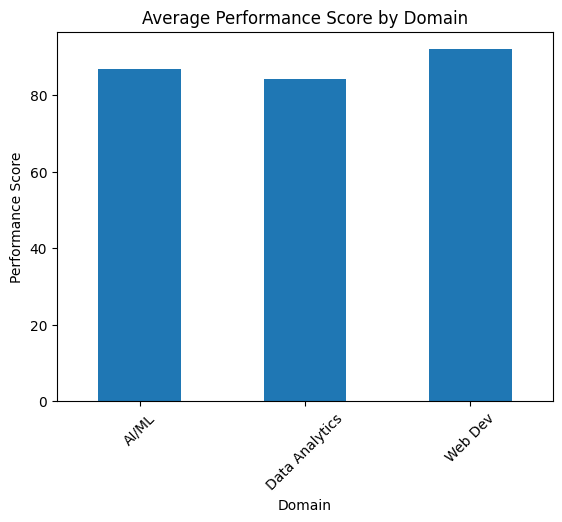

In [17]:
domain_perf = df.groupby("Domain")["Performance_Score"].mean()

plt.figure()
domain_perf.plot(kind="bar")
plt.title("Average Performance Score by Domain")
plt.xlabel("Domain")
plt.ylabel("Performance Score")
plt.xticks(rotation=45)
plt.show()

In [18]:
top_intern = df.groupby("Name")["Performance_Score"].mean().sort_values(ascending=False)
top_intern

,Performance_Score
Name,
Priya,94.833333
Rahul,89.000000
Neha,87.833333
Aisha,86.750000
Arjun,80.750000


In [8]:
df.to_excel("Intern_Performance_Report.xlsx", index=False)